## Loading the data

We load two GRIB files from the earthkit-data sample archive:

- `fc_storm_st_jude.grib` — the high-resolution deterministic forecast (HRES)
- `ens_storm_st_jude.grib` — the ensemble forecast (ENS), which contains 51 members: one control forecast (`cf`, member 0) and 50 perturbed forecasts (`pf`, members 1–50)

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

ds_fc = ekd.from_source("sample", "fc_storm_st_jude.grib")  # hi-res forecast
ds_en = ekd.from_source("sample", "ens_storm_st_jude.grib")  # ensemble forecast

fc_storm_st_jude.grib:   0%|          | 0.00/18.1k [00:00<?, ?B/s]

ens_storm_st_jude.grib:   0%|          | 0.00/938k [00:00<?, ?B/s]

# Spaghetti plots

A **spaghetti plot** overlays a single contour line — drawn at the same value — for every member of an ensemble forecast. The resulting tangle of lines gives an immediate visual impression of forecast uncertainty: where the lines cluster together the ensemble agrees; where they spread apart the forecast is uncertain.

This example uses ECMWF ensemble data from the [St Jude storm](https://en.wikipedia.org/wiki/2013_St._Jude_storm) (October 2013) to produce a spaghetti plot of the 850 hPa geopotential height field.

In [2]:
ds_fc.to_fieldlist().ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,10fg3,2013-10-28 00:00:00,2013-10-25,3 days 00:00:00,0,surface,0,regular_ll
1,10fg3,2013-10-28 06:00:00,2013-10-25,3 days 06:00:00,0,surface,0,regular_ll
2,10fg3,2013-10-28 12:00:00,2013-10-25,3 days 12:00:00,0,surface,0,regular_ll
3,z,2013-10-28 00:00:00,2013-10-25,3 days 00:00:00,850,pressure,0,regular_ll
4,z,2013-10-28 06:00:00,2013-10-25,3 days 06:00:00,850,pressure,0,regular_ll
5,z,2013-10-28 12:00:00,2013-10-25,3 days 12:00:00,850,pressure,0,regular_ll


## Inspecting the data

The deterministic forecast contains several fields. We can see it includes 10-metre wind gust (`10fg3`) and geopotential height (`z`) at 850 hPa, each at three lead times (00, 06, and 12 UTC on 28 October 2013).

In [3]:
z_fc = ds_fc.to_fieldlist().sel({"parameter.variable": "z", "vertical.level": 850, "time.step": 78})
z_en = ds_en.to_fieldlist().sel({"parameter.variable": "z", "vertical.level": 850, "time.step": 78})

## Selecting a single valid time

We select the 850 hPa geopotential field (`z`) at step 78 hours from both datasets. This corresponds to 00 UTC on 28 October 2013 — the time when the St Jude storm made landfall over north-west Europe.

Selecting by `time.step=78` ensures both the deterministic (`z_fc`) and ensemble (`z_en`) fields are at exactly the same valid time, making the comparison meaningful.

In [4]:
ds = z_en.to_xarray()
ds

<xarray.Dataset> Size: 608kB
Dimensions:    (member: 51, latitude: 31, longitude: 48)
Coordinates:
  * member     (member) <U2 408B '0' '1' '10' '11' '12' ... '50' '6' '7' '8' '9'
  * latitude   (latitude) float64 248B 66.0 65.25 64.5 63.75 ... 45.0 44.25 43.5
  * longitude  (longitude) float64 384B -19.5 -18.75 -18.0 ... 14.25 15.0 15.75
Data variables:
    z          (member, latitude, longitude) float64 607kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Examining the ensemble structure

Converting to xarray lets us inspect the shape of the ensemble. The dataset has a `member` dimension of size 51 (members 0–50), with a spatial grid of 31 × 48 points covering roughly 43–66°N, 20°W–16°E — a region centred on north-west Europe.

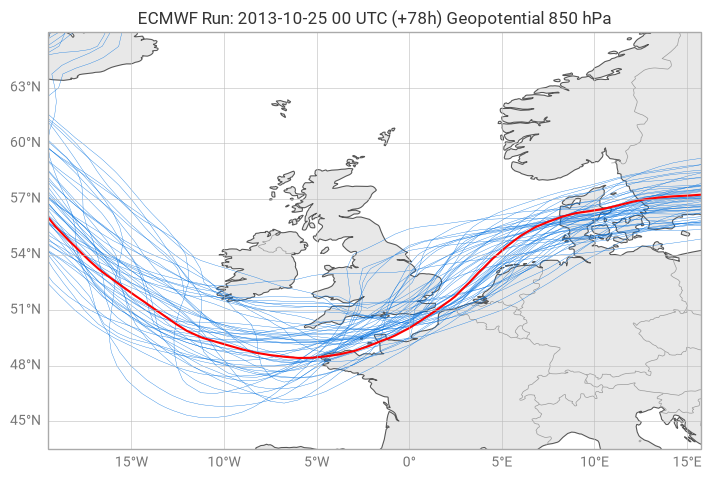

In [5]:
chart = ekp.Map(figsize=(7, 7))

# the isoline value (geopotential in m²/s²)
cont_level = [12500]

chart.spaghetti(
    z_en,
    levels=cont_level,
    highlight={"metadata.dataType": "cf"},
    label="Ensemble members",
)

chart.land()
chart.coastlines()
chart.borders()
chart.gridlines()

chart.title(
    "ECMWF Run: {base_time:%Y-%m-%d %H} UTC (+{lead_time}h) {variable_name} {level} hPa",
)

chart.legend()

chart.show()

## Plotting the spaghetti

`chart.spaghetti()` iterates over every member in the ensemble and draws a contour line at the chosen level for each one.

Key parameters:

- **`levels=[12500]`** — the geopotential value (in m²/s²) at which to draw the contour. A single isoline is drawn per member, which is the defining characteristic of a spaghetti plot.
- **`highlight={"metadata.dataType": "cf"}`** — picks out the control forecast member (member 0) and renders it in a distinct style so it stands apart from the perturbed members.
- **`label="foo"`** — assigns a legend label to the ensemble member lines.

Where the 51 lines overlap closely the ensemble is confident about the position of that height contour. Where they diverge — most visibly around the storm centre — the forecast is uncertain.